# Path integration

**Author:** Sibo Wang-Chen, Thomas Ka Chung Lam

**Summary:** In this tutorial, we will show how the position and heading of the animal can be estimated by integrating mechanosensory signals, a process known as path integration.

## Introduction

In the previous tutorials, we have demonstrated how brain-level processes can drive the motor system via _descending control_. _Ascending_ motor signals are a complement to descending information as they convey information, often mechanosensory in nature, back to the brain. Ascending signals are predicted to inform brain-level action selection, motor planning, and sensory contextualization (see [Chen et al., 2023](https://doi.org/10.1038/s41593-023-01281-z)). In this tutorial and the next, we will demonstrate how incorporating ascending motor feedback signals allows us to model behaviors that are critical to the animal's survival and functioning.

Animals, including flies, estimate their own orientation and distance traveled ("odometry") to perform path integration when navigating the world. A superb example of path integration was demonstrated in the desert ant _Cataglyphis fortis_ (see [review by Wolf, 2011](https://doi.org/10.1242/jeb.038570)). While the ant takes an exploratory outbound path in search of a food source, it can return to the nest in a straight line. Furthermore, if the experimenter moves the ant to a different location upon finding the food, the ant still takes the "correct" path back to the nest, but starting from the location where it has been "air dropped" (as shown below). These results show that the ant must be using idiothetic cues, rather than sensory input, to navigate — similar to how sailors used to navigate featureless oceans by "dead reckoning."

<p align="center">
<img src="assets/pathint_schematic.png" alt="pathint_schematic.png" width="300"/>
</p>

The fly _Drosophila melanogaster_ also performs path integration, especially when navigating to find food sources (see [Kim & Dickinson, 2017](https://doi.org/10.1016/j.cub.2017.06.026), [Behbahani et al., 2021](https://doi.org/10.1016/j.cub.2021.08.006)). While the source of the idiothetic cues are unknown, they may, in principle, be derived using ascending proprioceptive and tactile signals from the legs and motor system. As a demonstration, we will attempt to estimate the changes in the fly's orientation (shown below in green) and displacement (shown below in purple) based on proprioceptive and tactile information. By integrating these changes over time, we aim to reconstruct the path of the fly in space (right).

<p align="center">
<img src="assets/pathint_integration.png" alt="pathint_integration.png" width="600"/>
</p>

## The algorithm

We now make this path-integration strategy more precise. The task has two parts:

1. How can we predict heading change and forward displacement change from proprioceptive and tactile signals?
2. How can we integrate these estimated deltas to recover position over time?

For each leg, we accumulate stride length by tracking forward motion of the leg tip relative to the thorax while the leg is pushing. Proprioception provides leg-tip positions, and tactile signals indicate ground contact, which we use as a proxy for the pushing phase. For each leg pair, we compute left-right differences and sums of cumulative stride over a short time window. We then use linear regression to map these features to heading and forward-displacement changes.

A key detail is timescale. To predict _changes_, we must define a window length $\tau$. At each time step $t$, we compute feature deltas between $t-\tau$ and $t$. If these feature deltas predict heading/displacement deltas over the same window, we can divide by window length to obtain per-step estimates and integrate in 2D. The process is illustrated below:

<p align="center">
<img src="assets/pathint_prediction.png" alt="pathint_prediction.png" width="400"/>
</p>

In the next sections, we test this algorithm.

## Collecting walking data

To train the models, we first need to collect data where the fly walks in a trajectory similar to foraging desert ants. To this end, we will construct a scenario in which the fly model performs random exploration of a featureless environment. Here, the fly alternates between forward walking and in-place turning. We will control turning in a Poisson process with a rate $\lambda_\text{turn}=2\text{ s}^{-1}$. This turning rate is quite high compared to the range of typical fly behavior. This is to deliberately make path integration more difficult. When the fly executes a turn, we will apply a fixed asymmetrical descending drive of $[{\rm DN}_\text{inner}, {\rm DN}_\text{outer}] = [-0.2, 1.0]$.

The direction of the turn is chosen at random. We will sample the duration of the turn (and therefore the angle turned) from a normal distribution $\mathcal{N}(0.4\text{ s}, 0.1\text{ s})$. The fly receives no visual information — akin to navigating in the dark.

Let's define the discrete walking states as an `Enum` class (see [this tutorial](https://docs.python.org/3/howto/enum.html) for more information on Enum if you are not familiar with it, but this is not required).

In [2]:
from enum import Enum


class WalkingState(Enum):
    FWD = 0
    TURN_L = 1
    TURN_R = 2
    STOP = 3

Next, we will define a random exploration controller that controls the switch between straight walking and turning in a Poisson process, as discussed above. We will implement this controller as a class with a `.step` method, which returns the next state and the corresponding descending drives. Note that this controller is detached from the physics simulation — it only tells us which walking state the simulated fly _should_ be in in the next step.

In a Poisson process, the cumulative distribution function of the exponential distribution is
$$ F(x) = 1 - e^{-\lambda x} $$

Therefore, the probability that the transition will happen within the next $\Delta t$ seconds is
$$ P(T_{\rm turn} \leq {\rm d} t) = 1 - e^{-\lambda \Delta t} $$
where $\Delta t$ is the simulation time step and $T_{\rm turn}$ is the time until the next transition to turning. As a result, we will change the state to turning if and only if a scalar uniformly randomly sampled from 0 to 1 is greater than $e^{-\lambda \Delta t}$.

In [3]:
import numpy as np


class RandomExplorationController:
    """This controller drives a random exploration: the fly transitions
    between forward walking and turning in a Poisson process. When the fly
    turns, the turn direction is chosen randomly and the turn duration is
    drawn from a normal distribution.

    Parameters
    ----------
    dt : float
        Time step of the simulation.
    fwd_dn_drive : tuple[float, float], optional
        DN drives for forward walking, by default (1.0, 1.0).
    left_turn_dn_drive : tuple[float, float], optional
        DN drives for turning left, by default (-0.2, 1.0).
    right_turn_dn_drive : tuple[float, float], optional
        DN drives for turning right, by default (1.0, -0.2).
    turn_duration_mean : float, optional
        Mean of the turn duration distribution in seconds, by default
        0.4.
    turn_duration_std : float, optional
        Standard deviation of the turn duration distribution in
        seconds, by default 0.1.
    lambda_turn : float, optional
        Rate of the Poisson process for turning, by default 1.0.
    seed : int, optional
        Random seed, by default 0.
    init_time : float, optional
        Initial time, in seconds, during which the fly walks straight,
        by default 0.1.
    """

    def __init__(
        self,
        dt: float,
        fwd_dn_drive: tuple[float, float] = (1.0, 1.0),
        turn_l_dn_drive: tuple[float, float] = (-0.2, 1.0),
        turn_r_dn_drive: tuple[float, float] = (1.0, -0.2),
        turn_duration_mean: float = 0.4,
        turn_duration_std: float = 0.1,
        lambda_turn: float = 2.0,
        seed: int = 0,
        init_time: float = 0.1,
    ) -> None:
        self.random_state = np.random.RandomState(seed)
        self.dt = dt
        self.init_time = init_time
        self.curr_time = 0.0
        self.curr_state: WalkingState = WalkingState.FWD
        self._curr_turn_duration: float | None = None

        # DN drives
        self.dn_drives = {
            WalkingState.FWD: np.array(fwd_dn_drive),
            WalkingState.TURN_L: np.array(turn_l_dn_drive),
            WalkingState.TURN_R: np.array(turn_r_dn_drive),
        }

        # Turning related parameters
        self.turn_duration_mean = turn_duration_mean
        self.turn_duration_std = turn_duration_std
        self.lambda_turn = lambda_turn

    def step(self):
        """
        Update the fly's walking state.

        Returns
        -------
        WalkingState
            The next state of the fly.
        tuple[float, float]
            The next DN drives.
        """
        # Upon spawning, just walk straight for a bit (init_time) for things to settle
        if self.curr_time < self.init_time:
            self.curr_time += self.dt
            return WalkingState.FWD, self.dn_drives[WalkingState.FWD]

        # Forward -> turn transition
        if self.curr_state == WalkingState.FWD:
            p_nochange = np.exp(-self.lambda_turn * self.dt)
            if self.random_state.rand() > p_nochange:
                # decide turn duration and direction
                self._curr_turn_duration = self.random_state.normal(
                    self.turn_duration_mean, self.turn_duration_std
                )
                self.curr_state = self.random_state.choice(
                    [WalkingState.TURN_L, WalkingState.TURN_R]
                )
                self.curr_state_start_time = self.curr_time

        # Turn -> forward transition
        if self.curr_state in (WalkingState.TURN_L, WalkingState.TURN_R):
            if self.curr_time - self.curr_state_start_time > self._curr_turn_duration:
                self.curr_state = WalkingState.FWD
                self.curr_state_start_time = self.curr_time

        self.curr_time += self.dt
        return self.curr_state, self.dn_drives[self.curr_state]

We will implement a class to log the fly's position, heading, leg tip positions, and adhesion forces at every time step. This class will have a `.step` method that is called at every time step to save the logged variables.

In [4]:
from flygym.simulation import Simulation


class History:
    def __init__(self, n_steps: int, sim: Simulation, fly_name: str):
        self.pos = np.zeros((n_steps, 2), dtype=np.float32)
        self.heading = np.zeros(n_steps, dtype=np.float32)
        self.rel_leg_tip_pos = np.zeros((n_steps, 6), dtype=np.float32)
        self.adhesion_force = np.zeros((n_steps, 6), dtype=np.float32)

        body = sim.mj_data.body(f"{fly_name}/")
        self.curr_quat = body.xquat
        self.curr_pos = body.xpos[:2]
        legs = ["lf", "lm", "lh", "rf", "rm", "rh"]
        self.tarsus_ids = np.array(
            [sim.mj_data.body(f"{fly_name}/{leg}_tarsus5").id for leg in legs]
        )
        self.fly_name = fly_name
        self.sim = sim
        self.xpos = sim.mj_data.xpos[:, :2]

    def get_heading_vec(self):
        w, x, y, z = self.curr_quat
        return 1.0 - 2.0 * (y * y + z * z), 2.0 * (w * z + x * y)

    def get_rel_leg_tip_pos(self, heading_vec):
        leg_tip_pos = self.xpos[self.tarsus_ids]
        return (leg_tip_pos - self.curr_pos) @ heading_vec

    def step(self, i):
        heading_vec = self.get_heading_vec()
        self.rel_leg_tip_pos[i] = self.get_rel_leg_tip_pos(heading_vec)
        self.pos[i] = self.curr_pos
        self.heading[i] = np.arctan2(heading_vec[1], heading_vec[0])
        self.adhesion_force[i] = self.sim.get_adhesion_force_magnitudes(self.fly_name)

    def to_dict(self):
        return {
            "pos": self.pos,
            "heading": self.heading,
            "rel_leg_tip_pos": self.rel_leg_tip_pos,
            "adhesion_force": self.adhesion_force,
        }


Now, we are ready to write a `run_simulation` function that interfaces the state switching controller with the physics-embedded NeuroMechFly simulation:

In [5]:
from tqdm import trange
from flygym.compose.fly import ActuatorType
from flygym.compose.world import FlatGroundWorld
from flygym.utils.math import Rotation3D
from flygym.examples.locomotion import TurningController
from utils import create_fly, show_video


def run_simulation(seed=0, run_time=20.0, render=False):
    fly = create_fly()
    tracking_cam = fly.add_tracking_camera() if render else None
    world = FlatGroundWorld()
    world.add_fly(
        fly, spawn_position=(0, 0, 0.2), spawn_rotation=Rotation3D("quat", (1, 0, 0, 0))
    )
    sim = Simulation(world)

    if render:
        sim.set_renderer(
            camera=tracking_cam,
            playback_speed=0.2,
            output_fps=25,
        )

    exp_controller = RandomExplorationController(sim.timestep, seed=seed)
    turn_controller = TurningController(sim.timestep)

    for _ in range(500):
        sim.step()

    n_steps = int(run_time / sim.timestep)
    hist = History(n_steps, sim, fly.name)

    for i in trange(n_steps):
        walking_state, dn_drive = exp_controller.step()
        joint_angles, adhesion = turn_controller.step(dn_drive)
        sim.set_actuator_inputs(fly.name, ActuatorType.POSITION, joint_angles)
        sim.set_actuator_inputs(fly.name, ActuatorType.ADHESION, adhesion)
        sim.step()
        if render:
            sim.render_as_needed()
        hist.step(i)

    if render:
        show_video(sim)

    return hist.to_dict()

Let's run a 1-second simulation and plot the fly's trajectory:

In [6]:
data = run_simulation(seed=0, run_time=1.0, render=True)

100%|██████████| 10000/10000 [00:01<00:00, 6441.40it/s]


nmf/trackcam This browser does not support the video tag.


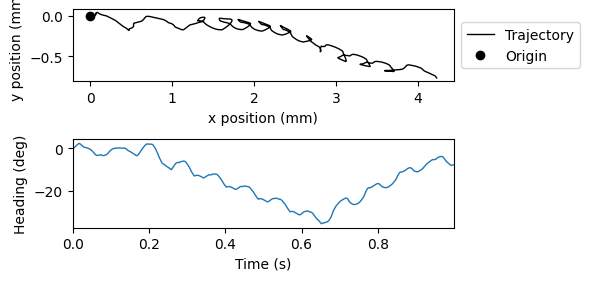

In [7]:
import matplotlib.pyplot as plt

timestep = 1e-4
pos = data["pos"]
heading = data["heading"]
rel_leg_tip_pos = data["rel_leg_tip_pos"]
adhesion_force = data["adhesion_force"]

fig, axs = plt.subplots(2, 1, figsize=(6, 3), tight_layout=True)
axs[0].plot(*pos.T, label="Trajectory", c="k", lw=1)
axs[0].plot([0], [0], "ko", label="Origin")
axs[0].legend(loc="center left", bbox_to_anchor=(1, 0.5))
axs[0].set_aspect("equal")
axs[0].set_xlabel("x position (mm)")
axs[0].set_ylabel("y position (mm)")

t = np.arange(heading.shape[0]) * timestep
axs[1].plot(t, np.rad2deg(np.unwrap(heading)), lw=1)
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Heading (deg)")
axs[1].margins(x=0)

We can also plot the recorded shifts in leg tip positions relative to the fly's thorax. This plot shows the time series of the change in the x position (along the anterior-posterior axis) of the leg tips from the previous time step. Note that the values can be both positive and negative. This is because we are simply reporting the shift in the leg tip positions without taking into account whether the legs are in stance or swing yet.

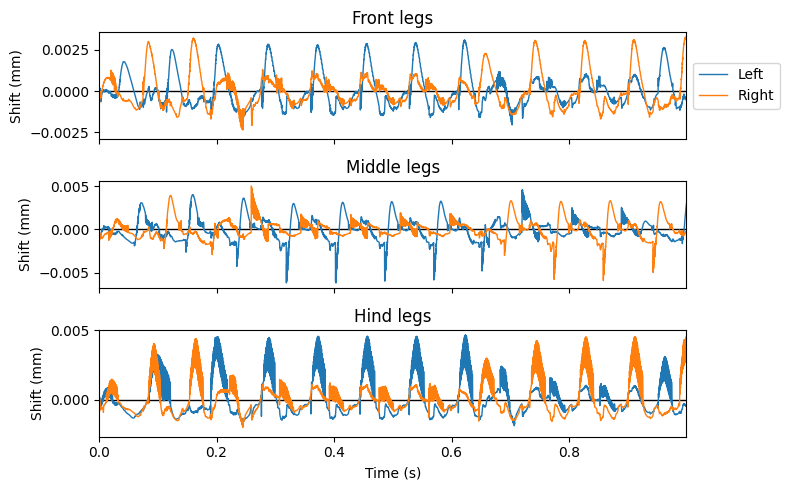

In [8]:
fig, axs = plt.subplots(3, 1, figsize=(8, 5), tight_layout=True, sharex=True)
for i, leg_pair in enumerate(["Front", "Middle", "Hind"]):
    ax = axs[i]
    ax.axhline(0, color="k", linestyle="-", lw=1)
    left_ts = np.diff(rel_leg_tip_pos[:, i])
    right_ts = np.diff(rel_leg_tip_pos[:, i + 3])
    t = np.arange(left_ts.shape[0]) * timestep
    ax.plot(t, left_ts, lw=1, label="Left")
    ax.plot(t, right_ts, lw=1, label="Right")
    if i == 0:
        ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    if i == 2:
        ax.set_xlabel("Time (s)")
    ax.set_ylabel("Shift (mm)")
    ax.set_title(f"{leg_pair} legs")
    ax.margins(x=0)

Let's also plot the adhesion force for each leg, which can be used as a proxy for whether the leg is contacting the ground, which in turn can be used as a proxy for whether the leg is pushing or swinging.

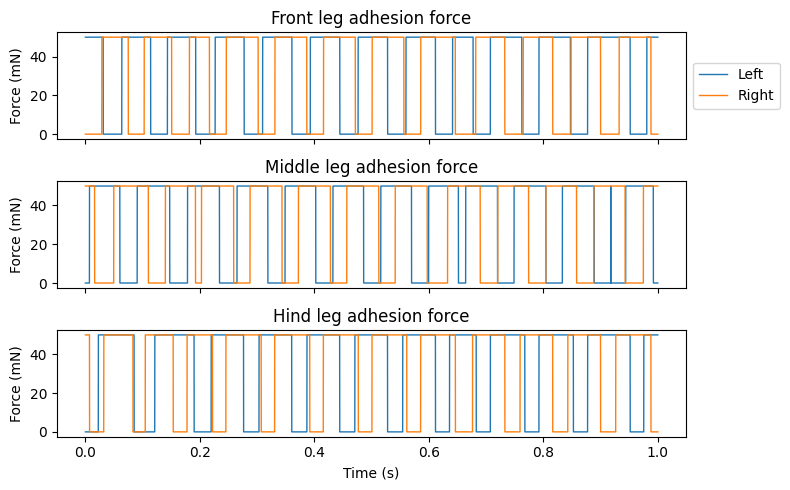

In [9]:
t = np.arange(adhesion_force.shape[0]) * 1e-4
fig, axs = plt.subplots(3, 1, figsize=(8, 5), tight_layout=True, sharex=True)
for i, leg_pair in enumerate(["Front", "Middle", "Hind"]):
    ax = axs[i]
    ax.plot(t, adhesion_force[:, i], lw=1, label="Left")
    ax.plot(t, adhesion_force[:, i + 3], lw=1, label="Right")
    ax.set_title(f"{leg_pair} leg adhesion force")
    ax.set_ylabel("Force (mN)")
    if i == 2:
        ax.set_xlabel("Time (s)")
axs[0].legend(loc="center left", bbox_to_anchor=(1, 0.5))

In the NeuroMechFly v2 paper, we ran 15 trials with different random seeds for each of the three gaits: tripod gait, tetrapod gait, and wave gait. Each trial was 20 seconds long. In this tutorial, we will use only 5 trials for the tripod gait.

In [10]:
from joblib import Parallel, delayed

all_data = Parallel(n_jobs=-1)(
    delayed(run_simulation)(seed=i, run_time=20) for i in range(5)
)

Recall the algorithm that we have proposed. To train the models, we need to collect the following _input_ variables to the model:

- Difference in the left-right _sum_ of cumulated stride lengths, `stride_cum_diff_lr_sum`
- Difference in the left-right _difference_ of cumulated stride lengths, `stride_cum_diff_lr_diff`

... and the following _target_ variables (i.e., what the models are supposed to predict):

- Difference in the fly's heading, `heading_diff`
- Difference in the fly's cumulative forward displacement, `fwd_disp_cum_diff`

There are two things to note here:

1. We have not implemented the calculation of stride lengths yet; `stride_diff_unmasked` is only the shift of the leg tip position from one time step to the next.
2. As discussed in the Algorithm section, the differences above are calculated over a predefined time scale $\tau$.

We will first calculate the unmasked stride differences for each leg at every time step:
$$
\text{stride\_diff\_unmasked}[i] =
    \text{rel\_leg\_tip\_pos}[i] - \text{rel\_leg\_tip\_pos}[i - 1]
$$

where $\text{rel\_leg\_tip\_pos}[i]$ is the position of the tip of this leg at the $i$-th step.

To calculate the cumulated stride lengths given `stride_diff_unmasked`, we need to mask it with a boolean time series indicating whether the leg is "pushing" (as opposed to swinging) before taking the cumulative sum. More precisely,

$$ 
\begin{gather*}
    \text{stride\_cum}[0] = 0 \\
    \text{stride\_cum}[i] = \text{stride\_cum}[i - 1] +
        \big( \text{mask}[i] \cdot \text{ stride\_diff\_unmasked}[i] \big)
    \quad \text{for } i > 0
\end{gather*}
$$

where $\text{mask}[i]$ is a boolean indicating whether the leg is in the power stroke (push). In our example, we will use the ground contact force to determine if the leg is in contact with the floor. If it is, then the leg is executing a power stroke. We will use a threshold of 0.5 mN, 1 mN, and 3mN for the front, middle, and hind legs respectively.

Once we have the cumulative stride lengths for each leg, we can calculate how it changes over the predefined time scale $\tau$:

$$
\text{stride\_win\_diff}[i] =
    \text{stride\_cum}[i] - \text{stride\_cum}[i - \text{win\_len}]
$$

where $\text{win\_len} = \tau / \Delta t$ is the number of simulation steps over the time scale $\tau$.

With this, we can finally calculate the changes in the left-right sum and left-right difference of cumulative stride lengths for each leg pair over time:

$$
\begin{align*}
    \text{stride\_win\_diff\_lr\_sum}[i] &= 
        \text{stride\_win\_diff}_\text{left}[i] +
        \text{stride\_win\_diff}_\text{right}[i] \\
    \text{stride\_win\_diff\_lr\_diff}[i] &= 
        \text{stride\_win\_diff}_\text{left}[i] -
        \text{stride\_win\_diff}_\text{right}[i] \\
\end{align*}
$$

Having extracted the _input_ variables, we now extract the target _output_ variables: heading change and forward-displacement change over the same time scale.

Heading change is straightforward. For each step $i$,

$$
\text{heading\_diff}[i] = \text{heading}[i] - \text{heading}[i - \text{win\_len}]
\quad \text{wrapped to } [-\pi, \pi)
$$

where $\text{heading}$ is the heading angle.

For forward displacement, we first accumulate per-step forward motion into $\text{fwd\_disp\_cum}$. This differs from total traveled distance because we project each step onto the instantaneous heading and discard lateral motion.

$$
\begin{gather*}
    \text{fwd\_disp\_cum}[0] = 0, \\
    \text{fwd\_disp\_cum}[i] =
        \text{fwd\_disp\_cum}[i - 1] + \text{fwd\_disp}[i]
    \quad \text{for } i > 0
\end{gather*}
$$

with

$$
\text{fwd\_disp}[i] = (\overrightarrow{\text{pos}}[i] -
        \overrightarrow{\text{pos}}[i - 1]) \cdot
        \begin{bmatrix}
            \cos(\text{heading}[i])\\
            \sin(\text{heading}[i])
        \end{bmatrix}
$$

where $\overrightarrow{\text{pos}}[i]$ is the fly's 2D position at step $i$.

Then the windowed forward-displacement change is

$$
\text{fwd\_disp\_win\_diff}[i] =
    \text{fwd\_disp\_cum}[i] -
    \text{fwd\_disp\_cum}[i - \text{win\_len}]
$$

Let's implement a function that extracts these variables:

In [11]:
def wrap_to_pi(angle: np.ndarray) -> np.ndarray:
    """Wrap angle(s) in radians to the interval [-pi, pi)."""
    return (angle + np.pi) % (2 * np.pi) - np.pi


def get_variables(
    data: dict[str, np.ndarray],
    win_len: int,
    adhesion_force_thr: float,
) -> dict[str, np.ndarray]:
    """Extract path-integration input/target variables from raw trial data."""
    if win_len <= 0:
        raise ValueError("win_len must be a positive integer.")
    if data["pos"].shape[0] <= win_len:
        raise ValueError("Data length must be greater than win_len.")

    def win_diff(a: np.ndarray) -> np.ndarray:
        return a[win_len:] - a[:-win_len]

    pos = data["pos"]
    heading = data["heading"]
    stride_diff_unmasked = np.diff(data["rel_leg_tip_pos"], axis=0, prepend=0)
    adhesion_force = data["adhesion_force"]

    # Mechanosensory variables
    mask = adhesion_force >= adhesion_force_thr
    stride_cum = np.cumsum(mask * stride_diff_unmasked, axis=0)
    stride_win_diff = win_diff(stride_cum)

    stride_win_diff_l = stride_win_diff[:, :3]
    stride_win_diff_r = stride_win_diff[:, 3:6]
    stride_win_diff_lr_sum = stride_win_diff_l + stride_win_diff_r
    stride_win_diff_lr_diff = stride_win_diff_l - stride_win_diff_r

    # Locomotion-state targets
    heading_win_diff = wrap_to_pi(win_diff(heading))
    pos_diff = np.diff(pos, axis=0, prepend=0)
    heading_vec = np.stack([np.cos(heading), np.sin(heading)], axis=-1)
    fwd_disp_mag = np.einsum("ij,ij->i", pos_diff, heading_vec)
    fwd_disp_cum = np.cumsum(fwd_disp_mag)
    fwd_disp_win_diff = win_diff(fwd_disp_cum)

    return {
        "stride_win_diff_lr_sum": stride_win_diff_lr_sum,
        "stride_win_diff_lr_diff": stride_win_diff_lr_diff,
        "heading_win_diff": heading_win_diff,
        "fwd_disp_win_diff": fwd_disp_win_diff,
    }

Let's use this function to extract the input and target variables at a time scale of 0.32 s using a contact force threshold of 25 mN:

In [12]:
time_scale = 0.32
time_step = 1e-4
win_len = int(time_scale / time_step)
adhesion_force_thr = 25
extracted_vars = [get_variables(data, win_len, adhesion_force_thr) for data in all_data]

We are trying to predict the change in forward displacement from the changes in left-right sums, and the change in heading from the left-right differences. Let's plot these variable in one trial to decide if these are qualitatively good predictors:

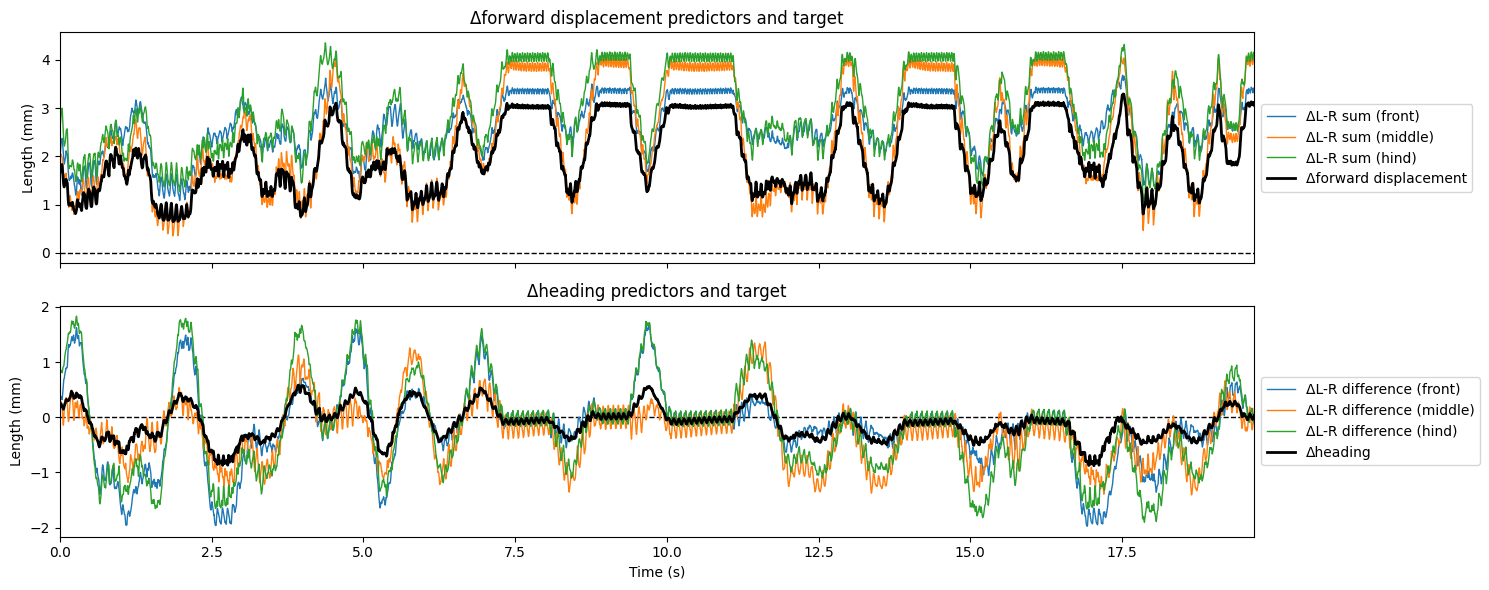

In [13]:
trial_vars = extracted_vars[0]
t = np.arange(trial_vars["stride_win_diff_lr_sum"].shape[0]) * time_step
fig, axs = plt.subplots(2, 1, figsize=(15, 6), tight_layout=True, sharex=True)

axs[0].axhline(0, color="k", linestyle="--", lw=1)
for i, leg in enumerate(["Front", "Middle", "Hind"]):
    axs[0].plot(
        t,
        -trial_vars["stride_win_diff_lr_sum"][:, i],
        lw=1,
        label=f"ΔL-R sum ({leg.lower()})",
    )

axs[0].plot(
    t, trial_vars["fwd_disp_win_diff"], lw=2, color="k", label="Δforward displacement"
)
axs[0].legend(loc="center left", bbox_to_anchor=(1, 0.5))
axs[0].set_ylabel("Length (mm)")
axs[0].set_title("Δforward displacement predictors and target")

axs[1].axhline(0, color="k", linestyle="--", lw=1)
for i, leg in enumerate(["Front", "Middle", "Hind"]):
    axs[1].plot(
        t,
        -trial_vars["stride_win_diff_lr_diff"][:, i],
        lw=1,
        label=f"ΔL-R difference ({leg.lower()})",
    )

axs[1].plot(t, -trial_vars["heading_win_diff"], lw=2, color="k", label="Δheading")
axs[1].legend(loc="center left", bbox_to_anchor=(1, 0.5))
axs[1].set_ylabel("Length (mm)")
axs[1].set_xlabel("Time (s)")
axs[1].set_title("Δheading predictors and target")
for ax in axs:
    ax.margins(x=0)

We observe that the inputs (blue, orange, and green lines) indeed seem to be good predictors of the target (black lines). Next, we will train the prediction models based on our proposed algorithm.

## Training models to predict changes in locomotor state

Once inputs and targets are extracted, model fitting is straightforward. We train two linear models:

$$
\begin{align*}
    \text{heading\_win\_diff\_pred}[i] &= 
        \sum_{pos\in\{\text{front}, \text{middle}, \text{hind}\}}
            \big(
                k_{pos}^{({\rm h})} \cdot \text{stride\_win\_diff\_lr\_diff}_{pos}[i]
            \big) + b^{({\rm h})} \\
    \text{fwd\_disp\_win\_diff\_pred}[i] &= 
        \sum_{pos\in\{\text{front}, \text{middle}, \text{hind}\}}
            \big(
                k_{pos}^{({\rm fwd})} \cdot \text{stride\_win\_diff\_lr\_sum}_{pos}[i]
            \big) + b^{({\rm fwd})} \\
\end{align*}
$$

where $\text{heading\_win\_diff\_pred}$ and $\text{fwd\_disp\_win\_diff\_pred}$ are predictions of $\text{heading\_win\_diff}$ and $\text{fwd\_disp\_win\_diff}$ respectively, and $k_{pos}^{({\rm h})}$, $b^{({\rm h})}$, $k_{pos}^{({\rm fwd})}$, and $b^{({\rm fwd})}$ are fitted parameters.

We have 5 trials in total. We concatenate the first 4 for training and reserve the last trial for testing.

In [14]:
stride_win_diff_lr_sum_train = np.concatenate(
    [v["stride_win_diff_lr_sum"] for v in extracted_vars[:4]]
)
stride_win_diff_lr_diff_train = np.concatenate(
    [v["stride_win_diff_lr_diff"] for v in extracted_vars[:4]]
)
heading_win_diff_train = np.concatenate(
    [v["heading_win_diff"] for v in extracted_vars[:4]]
)
fwd_disp_win_diff_train = np.concatenate(
    [v["fwd_disp_win_diff"] for v in extracted_vars[:4]]
)

stride_win_diff_lr_sum_test = extracted_vars[4]["stride_win_diff_lr_sum"]
stride_win_diff_lr_diff_test = extracted_vars[4]["stride_win_diff_lr_diff"]
heading_win_diff_test = extracted_vars[4]["heading_win_diff"]
fwd_disp_win_diff_test = extracted_vars[4]["fwd_disp_win_diff"]

In [15]:
from sklearn.linear_model import LinearRegression


def fit_model(x: np.ndarray, y: np.ndarray) -> tuple[LinearRegression, float]:
    model = LinearRegression()
    model.fit(x, y)
    r2 = model.score(x, y)
    return model, r2


heading_model, heading_r2 = fit_model(
    stride_win_diff_lr_diff_train, heading_win_diff_train
)
fwd_disp_model, fwd_disp_r2 = fit_model(
    stride_win_diff_lr_sum_train, fwd_disp_win_diff_train
)

print("Δheading model:")
print(f"  coefficients (front, middle, hind legs): {heading_model.coef_}")
print(f"  intercept: {heading_model.intercept_}")
print(f"  r2 score (training set): {heading_r2}")
print("Δforward displacement model:")
print(f"  coefficients (front, middle, hind legs): {fwd_disp_model.coef_}")
print(f"  intercept: {fwd_disp_model.intercept_}")
print(f"  r2 score (training set): {fwd_disp_r2}")

Δheading model:
  coefficients (front, middle, hind legs): [0.22439648 0.26674613 0.02882383]
  intercept: -0.003790784728957046
  r2 score (training set): 0.9709927361890961
Δforward displacement model:
  coefficients (front, middle, hind legs): [-0.25451458 -0.48416917 -0.0847495 ]
  intercept: -0.031104178240722646
  r2 score (training set): 0.9880558038071706


## Integrating changes in locomotor state to estimate position

Now that we have built models that can estimate the changes in heading and forward displacement, we will integrate these changes to estimate the fly's location in space. To do this, we essentially reverse the process of extracting the change signals: whereas previously we have taken the per-step changes in cumulative stride lengths as an estimation of instantaneous changes, we will now sum these changes as an approximation of continuous integration.

More formally, from the model-predicted change in heading, $\text{heading\_diff\_pred}$, the estimated heading can be given by
$$
\text{heading\_pred}[i] =
    \sum_{i'=0}^i \frac{\text{heading\_diff\_pred}[i']}{\text{win\_len}}
$$
where, once again, $\text{win\_len} = \tau / \Delta t$ is the number of simulation steps over the time scale $\tau$.

To obtain the estimated position vector, $\overrightarrow{\text{pos\_pred}}$, we have to take into account the fact that the change in _forward_ displacement must be integrated in the direction of the fly's instantaneous heading:
$$
\overrightarrow{\text{pos\_pred}}[i] =
    \sum_{i'=0}^i \frac{\text{fwd\_disp\_diff\_pred}[i']}{\text{win\_len}}
    \begin{bmatrix}
        \cos(\text{heading\_pred}[i'])\\
        \sin(\text{heading\_pred}[i'])
    \end{bmatrix}
$$

We will now implement this integration logic:

In [16]:
from typing import Callable


def path_integrate(
    data: dict[str, np.ndarray],
    heading_model: Callable[[np.ndarray], np.ndarray],
    fwd_disp_model: Callable[[np.ndarray], np.ndarray],
    win_len: int,
    adhesion_force_thr: float,
):
    """Perform path integration on one trial."""
    variables = get_variables(data, win_len, adhesion_force_thr)

    # Integrate heading
    heading_win_diff_pred = np.asarray(
        heading_model(variables["stride_win_diff_lr_diff"]), dtype=np.float64
    )
    heading_pred = np.cumsum(heading_win_diff_pred / win_len)
    real_heading_start = data["heading"][win_len]
    heading_pred += real_heading_start

    # Integrate displacement
    fwd_disp_win_diff_pred = np.asarray(
        fwd_disp_model(variables["stride_win_diff_lr_sum"]), dtype=np.float64
    )
    heading_vec_pred = np.stack([np.cos(heading_pred), np.sin(heading_pred)], axis=-1)
    disp_pred = fwd_disp_win_diff_pred[..., None] * heading_vec_pred / win_len
    pos_pred = np.cumsum(disp_pred, axis=0) + data["pos"][win_len]

    # Pad with NaN where prediction is undefined
    padding = np.full(win_len, np.nan)
    heading_pred = np.concatenate([padding, heading_pred])
    pos_pred = np.concatenate([np.full((win_len, 2), np.nan), pos_pred], axis=0)
    heading_win_diff_pred = np.concatenate([padding, heading_win_diff_pred])
    heading_win_diff_actual = np.concatenate([padding, variables["heading_win_diff"]])
    fwd_disp_win_diff_pred = np.concatenate([padding, fwd_disp_win_diff_pred])
    fwd_disp_win_diff_actual = np.concatenate([padding, variables["fwd_disp_win_diff"]])

    return {
        "heading_pred": heading_pred,
        "heading_actual": data["heading"],
        "pos_pred": pos_pred,
        "pos_actual": data["pos"],
        "heading_win_diff_pred": heading_win_diff_pred,
        "heading_win_diff_actual": heading_win_diff_actual,
        "fwd_disp_win_diff_pred": fwd_disp_win_diff_pred,
        "fwd_disp_win_diff_actual": fwd_disp_win_diff_actual,
    }

We can run this function on the last trial, which has been reserved for testing:

In [17]:
res = path_integrate(
    all_data[-1],
    heading_model.predict,
    fwd_disp_model.predict,
    win_len=win_len,
    adhesion_force_thr=adhesion_force_thr,
)

... and inspect the time series of predicted vs. actual changes in heading and forward displacement on this test dataset.

Text(0.5, 0, 'Time (s)')

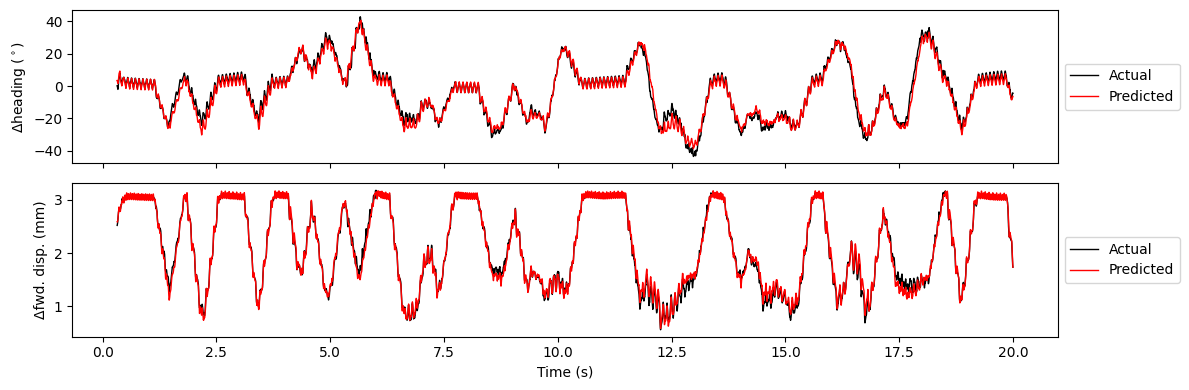

In [18]:
fig, axs = plt.subplots(2, 1, figsize=(12, 4), tight_layout=True, sharex=True)
t = np.arange(res["heading_win_diff_actual"].shape[0]) * time_step
axs[0].plot(t, np.rad2deg(res["heading_win_diff_actual"]), lw=1, c="k", label="Actual")
axs[0].plot(t, np.rad2deg(res["heading_win_diff_pred"]), lw=1, c="r", label="Predicted")
axs[0].set_ylabel(r"Δheading ($^\circ$)")
axs[0].legend(loc="center left", bbox_to_anchor=(1, 0.5))
axs[1].plot(t, res["fwd_disp_win_diff_actual"], lw=1, c="k", label="Actual")
axs[1].plot(t, res["fwd_disp_win_diff_pred"], lw=1, c="r", label="Predicted")
axs[1].set_ylabel("Δfwd. disp. (mm)")
axs[1].legend(loc="center left", bbox_to_anchor=(1, 0.5))
axs[1].set_xlabel("Time (s)")

Similarly, we can plot the integrated estimation of heading and cumulative forward displacement:

Text(0.5, 0, 'Time (s)')

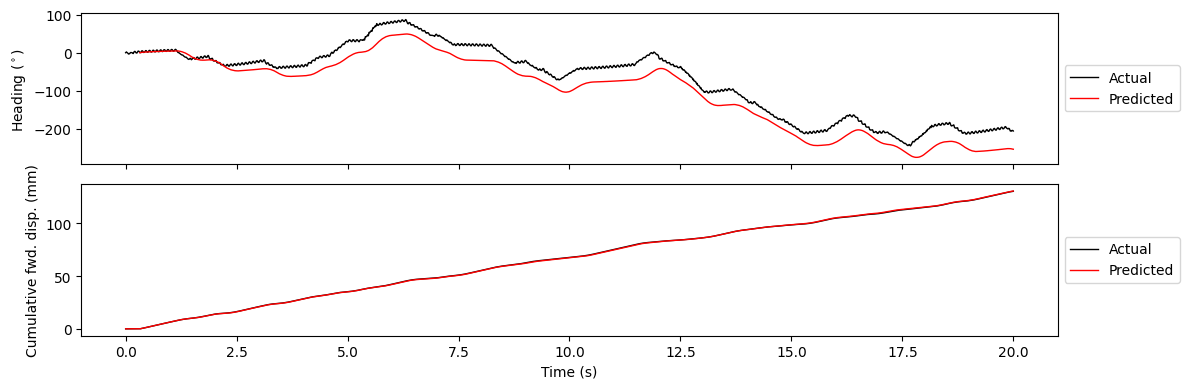

In [19]:
fig, axs = plt.subplots(2, 1, figsize=(12, 4), tight_layout=True, sharex=True)

heading_actual = np.rad2deg(np.unwrap(res["heading_actual"]))
heading_pred = np.rad2deg(res["heading_pred"])
axs[0].plot(t, heading_actual, lw=1, c="k", label="Actual")
axs[0].plot(t, heading_pred, lw=1, c="r", label="Predicted")
axs[0].set_ylabel(r"Heading ($^\circ$)")
axs[0].legend(loc="center left", bbox_to_anchor=(1, 0.5))

fwd_disp_cum_actual = (
    np.cumsum(np.nan_to_num(res["fwd_disp_win_diff_actual"])) / win_len
)
fwd_disp_cum_pred = np.cumsum(np.nan_to_num(res["fwd_disp_win_diff_pred"])) / win_len
axs[1].plot(t, fwd_disp_cum_actual, lw=1, c="k", label="Actual")
axs[1].plot(t, fwd_disp_cum_pred, lw=1, c="r", label="Predicted")
axs[1].set_ylabel("Cumulative fwd. disp. (mm)")
axs[1].legend(loc="center left", bbox_to_anchor=(1, 0.5))
axs[1].set_xlabel("Time (s)")

Finally, we can plot the estimated and true trajectories of the fly:

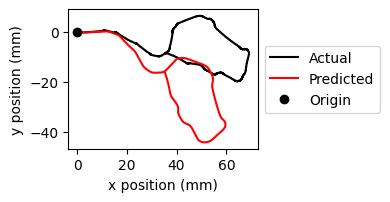

In [20]:
fig, ax = plt.subplots(figsize=(4, 4), tight_layout=True)
ax.plot(*res["pos_actual"].T, c="k", label="Actual")
ax.plot(*res["pos_pred"].T, c="r", label="Predicted")
ax.plot([0], [0], "ko", label="Origin")
ax.set_aspect("equal")
ax.set_xlabel("x position (mm)")
ax.set_ylabel("y position (mm)")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

We can observe that, although the model gives excellent predictions in heading and forward displacement, small errors in heading can lead to larger errors in the final position estimation. This is simply due to the fact that walking straight in a slightly wrong direction amplifies the error in the estimated position. Therefore, while path integration based solely on idiothetic cues is possible, calibration of the integrator based on sensory inputs appears to be critical.